In [24]:
import xarray as xr
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 14
})
import matplotlib.cm as cm


In [25]:
dummy = xr.open_mfdataset("/pscratch/sd/a/amahesh/hens/demo_bred_1step/ensemble_out_0000*_2020-06-18-00-00-00.nc",
                     group='global', concat_dim='ensemble', combine='nested')

In [26]:
def load_small_ens(curr_date):
    PATH = f"/pscratch/sd/a/amahesh/hens/time_collection/bred_29multicheckpoint_pert0p35_k1i3_500km_oppositepert_detfix_nodpr_timeevolve_hemisphererescale_target48_20minus20_newseed_repeat_qperturbfix_rankhist_qmin0_summer2023/{curr_date.year}-{curr_date.month:02d}-{curr_date.day:02d}T00:00:00/"
    mse = xr.open_zarr(f"{PATH}/ensemble_mse.zarr", decode_times=False)
    variance = xr.open_zarr(f"{PATH}/variance.zarr", decode_times=False)
    return mse['t2m'], variance['t2m']

In [27]:
dates = pd.date_range('2023-06-01', '2023-08-31', freq='D')
variance, mse, small_variance_list, small_mse_list = [], [], [], []
for idx, curr_date in enumerate(dates):
    val = xr.open_mfdataset(f"/pscratch/sd/a/amahesh/hens_h5/stats/t2m_{curr_date:%Y%m%d}_reduced-lead-04-07-10.h5")
    val = val.rename({"phony_dim_2" : 'lat',
                     "phony_dim_3" : 'lon',
                     'phony_dim_1' : 'time'})
    val['lat'] = dummy['lat']
    val['lon'] = dummy['lon']
    variance.append(val['t2m_var'][idx])
    mse.append(val['t2m_ens_mse'][idx])

    small_mse, small_variance = load_small_ens(curr_date)
    
    small_variance_list.append(small_variance)
    small_mse_list.append(small_mse)



In [28]:
variance = xr.concat(variance, dim='initial_time').mean('initial_time')
mse = xr.concat(mse, dim='initial_time').mean('initial_time')
small_variance_list = xr.concat(small_variance_list, dim='initial_time').mean('initial_time')
small_mse_list = xr.concat(small_mse_list, dim='initial_time').mean('initial_time')


In [29]:
def global_mean(ds):
    weights = np.cos(np.deg2rad(ds.lat))
    return ds.weighted(weights).mean('lat').mean('lon')
def global_root_mean(ds):
    weights = np.cos(np.deg2rad(ds.lat))
    return np.sqrt(ds.weighted(weights).mean('lat').mean('lon'))

In [30]:
variance = global_mean(variance)
mse = global_mean(mse)
small_mse_list = global_mean(small_mse_list)
small_variance_list = global_mean(small_variance_list)

In [31]:
viridis = cm.get_cmap('viridis')

# Get the extreme colors from the colormap
color_58_members = viridis(0)  # First color in viridis
color_7424_members = viridis(235)  # Last color in viridis

/tmp/ipykernel_2140411/3787945476.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  viridis = cm.get_cmap('viridis')


In [33]:
variance['time'] = np.asarray([16, 17, 18, 19, 28, 29, 30, 31, 40, 41, 42, 43]) * 6

In [12]:
viridis = cm.get_cmap('viridis')

# Get the extreme colors from the colormap
color_58_members = viridis(0)  # First color in viridis
color_7424_members = viridis(235)  # Last color in viridis

/tmp/ipykernel_1718928/3787945476.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  viridis = cm.get_cmap('viridis')


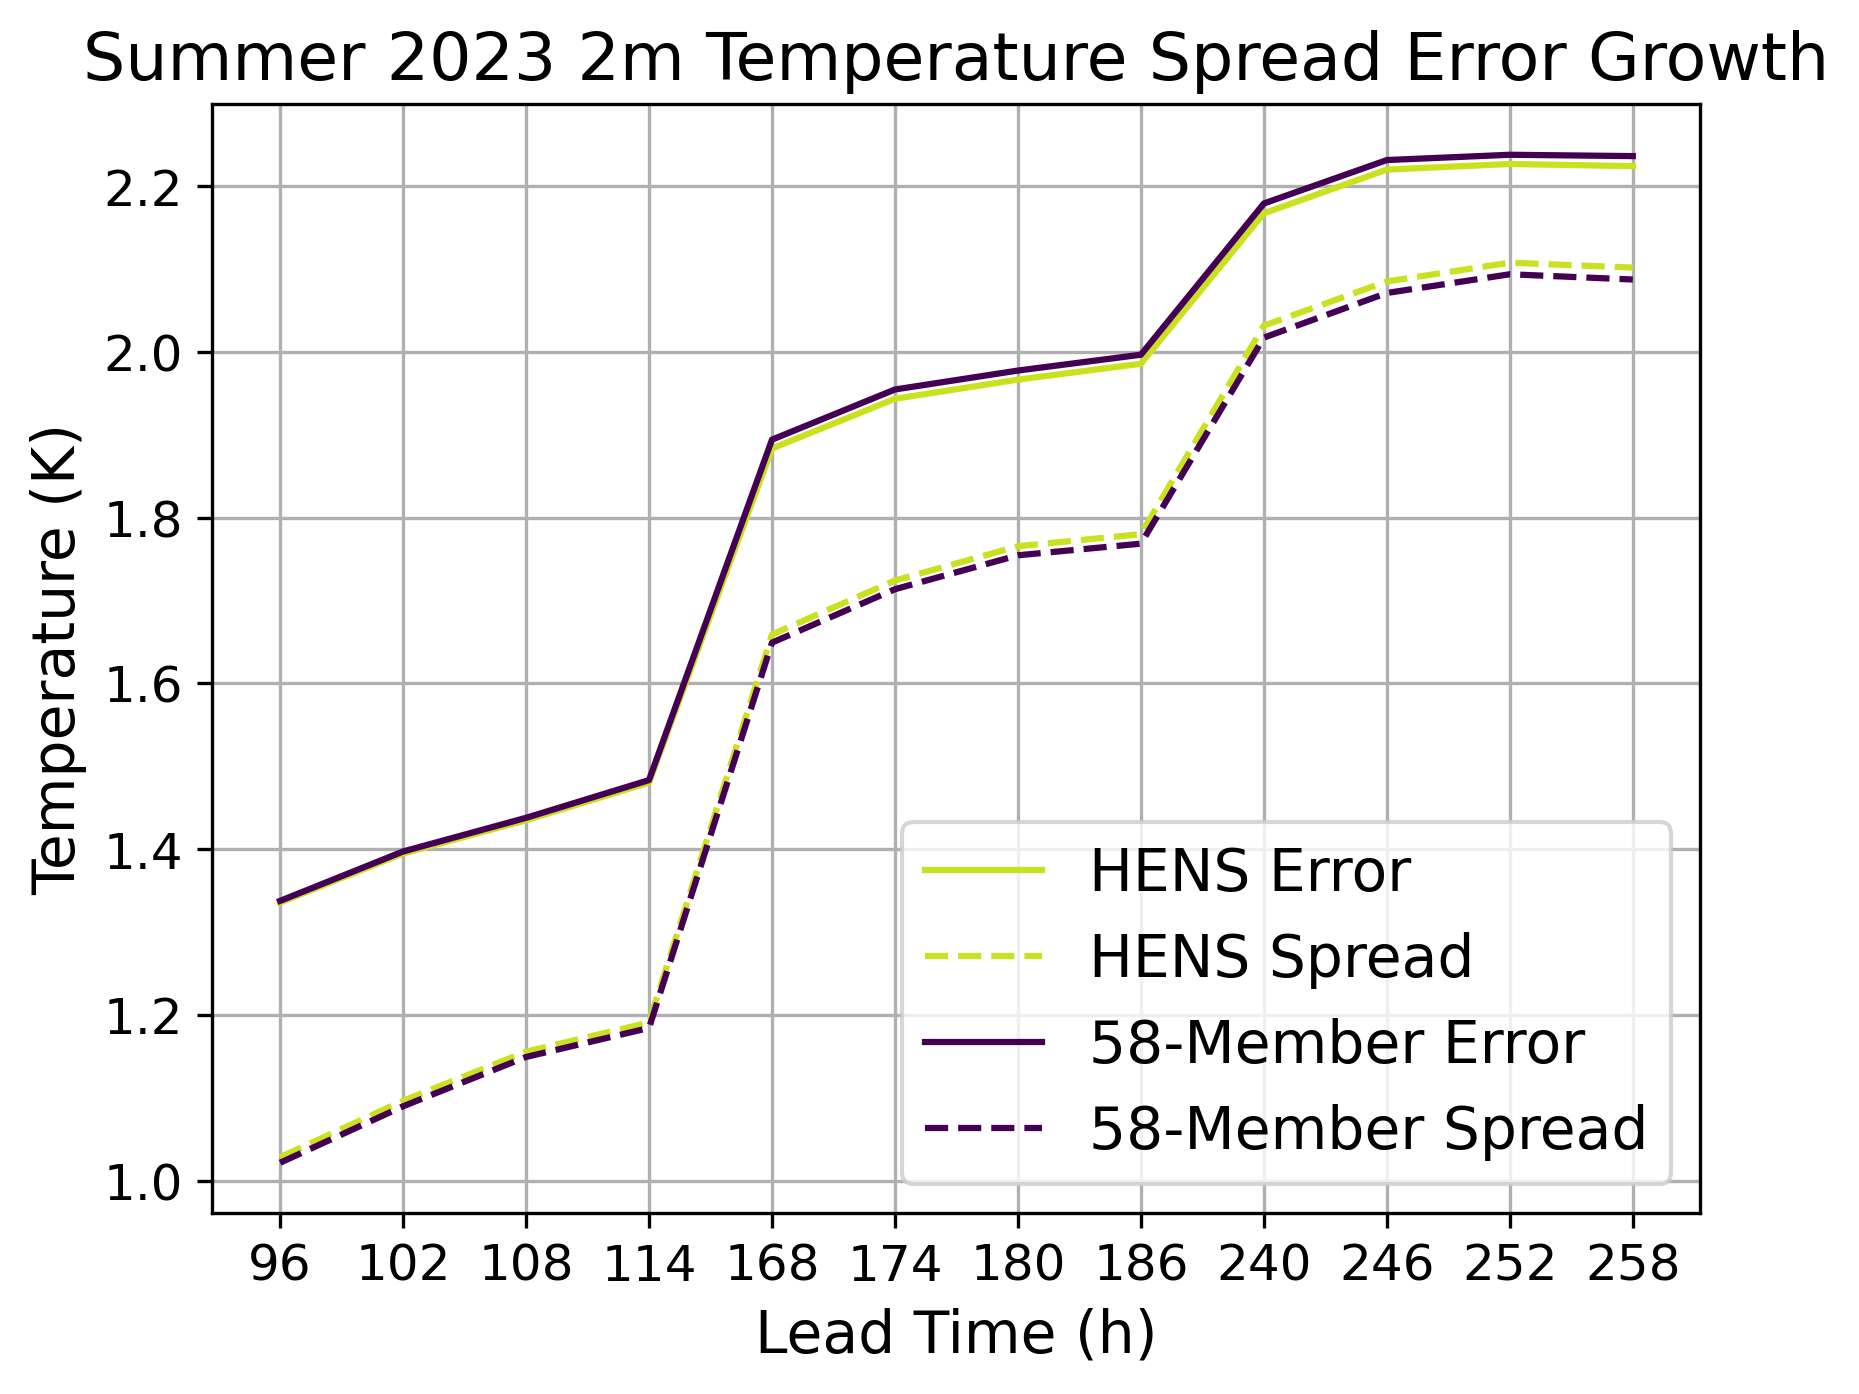

In [40]:
plt.figure(dpi=300)
plt.plot((mse) ** 0.5, label='HENS Error', color=color_7424_members)
plt.plot(((variance) ** 0.5).sel(time=variance['time']), label='HENS Spread', linestyle='dashed',
                                                                             color=color_7424_members)
plt.plot((small_mse_list ** 0.5).sel(time=variance['time']), label='58-Member Error', color=color_58_members)
plt.plot(((small_variance_list) ** 0.5).sel(time=variance['time']), label='58-Member Spread', linestyle='dashed',
                                                                             color=color_58_members)
plt.grid()
plt.xlabel("Lead Time (h)")
plt.ylabel("Temperature (K)")
plt.title("Summer 2023 2m Temperature Spread Error Growth")
plt.legend()
plt.xticks(np.arange(12), labels= np.array([16,17,18,19,28,29,30,31,40,41,42,43])*6)
plt.savefig("spread_error_growth.pdf")
plt.show()